In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
print("Python is working!")

Python is working!


In [1]:
import pandas as pd

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print(trades.shape)
print(sentiment.shape)

(211224, 16)
(2644, 4)


In [2]:
import os

os.listdir()

['Untitled.ipynb',
 'fear_greed_index.csv',
 'historical_data.csv',
 'notebooks',
 'README.md',
 'data']

In [4]:
print("TRADES COLUMNS:")
print(trades.columns)

print("\nSENTIMENT COLUMNS:")
print(sentiment.columns)

TRADES COLUMNS:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

SENTIMENT COLUMNS:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [6]:
trades["Date"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
).dt.date

sentiment["Date"] = pd.to_datetime(
    sentiment["date"]
).dt.date

print("Date conversion successful")

Date conversion successful


In [7]:
merged = pd.merge(
    trades,
    sentiment[["Date", "classification"]],
    on="Date",
    how="inner"
)

print("Merged Shape:", merged.shape)

Merged Shape: (211218, 18)


In [8]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [9]:
print(merged.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'classification'],
      dtype='object')


In [10]:
avg_profit = merged.groupby(
    "classification"
)["Closed PnL"].mean()

print(avg_profit)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [11]:
total_profit = merged.groupby(
    "classification"
)["Closed PnL"].sum()

print(total_profit)

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


In [12]:
merged["Win"] = merged["Closed PnL"] > 0

win_rate = merged.groupby(
    "classification"
)["Win"].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


In [13]:
avg_size = merged.groupby(
    "classification"
)["Size USD"].mean()

print(avg_size)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


In [14]:
buy_sell = merged.groupby(
    ["classification", "Side"]
)["Closed PnL"].mean()

print(buy_sell)

classification  Side
Extreme Fear    BUY      34.114627
                SELL     34.980106
Extreme Greed   BUY      10.498927
                SELL    114.584643
Fear            BUY      63.927104
                SELL     45.049641
Greed           BUY      25.002302
                SELL     59.691091
Neutral         BUY      29.227429
                SELL     39.456408
Name: Closed PnL, dtype: float64


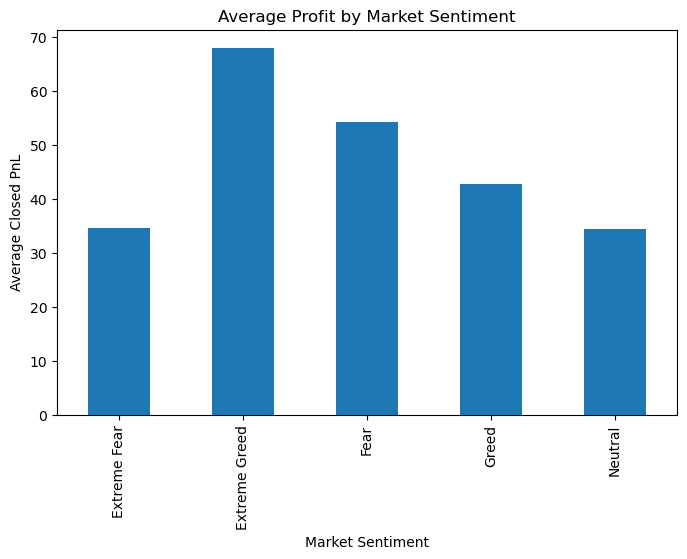

In [16]:
import matplotlib.pyplot as plt

avg_profit.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Profit by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xlabel("Market Sentiment")

plt.show()

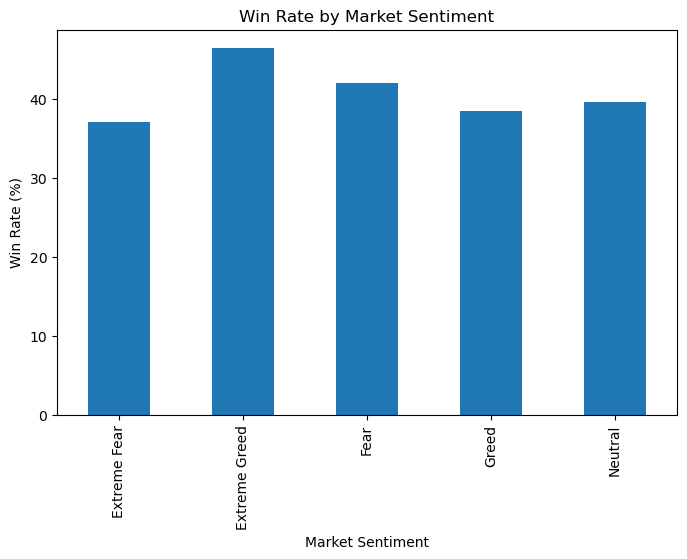

In [17]:
import matplotlib.pyplot as plt

win_rate.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xlabel("Market Sentiment")

plt.show()

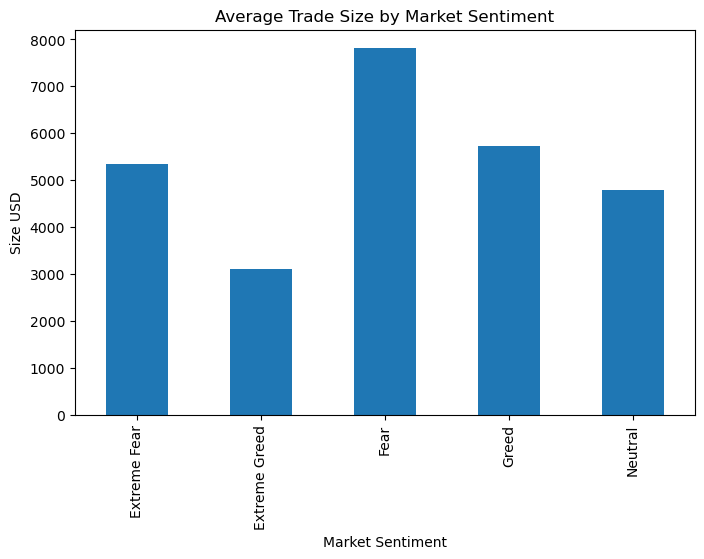

In [18]:
import matplotlib.pyplot as plt

avg_size.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Trade Size by Market Sentiment")
plt.ylabel("Size USD")
plt.xlabel("Market Sentiment")

plt.show()

# Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

# Dataset Sources

1. Historical Trader Data
2. Bitcoin Fear & Greed Index

# Author

Pranjal Patil